In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad

The following code will generate $x_0$ and $x_1$ via a swiss roll data set. \
I plotted the data for easy visualization. The red triangles represent $X_1$ and black triangles represent $X_0$.

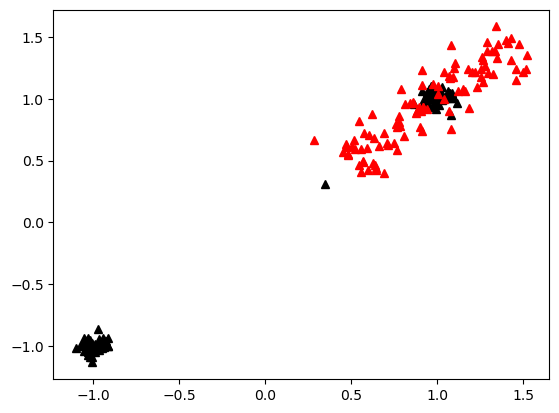

In [4]:
def get_matching_data(N=100, noise=0.05):
    # Make the swiss roll dataset
    t = 3*torch.pi/2 * (1 + 2*torch.rand(1,N))
    z = noise * torch.randn(2,N)
    X1 = torch.cat([t*torch.cos(t),t*torch.sin(t)], dim=0)
    X1 = (X1 + z)/10
    X1 = 0.1*torch.randn(2, N) + 0.1*t
    tm = t - t.mean()
    X2 = torch.cat((torch.tanh(10*tm), torch.tanh(10*tm)), dim=0)
    X2 = X2 + z
    	
    return X1.t(), X2.t()

X1, X0 = get_matching_data(N=100, noise=0.05)

plt.plot(X0[:,0],X0[:,1],'^k')
plt.plot(X1[:,0],X1[:,1],'^r')

I solved the ODE using the Forward Euler Integration in the form of: 
$$ {\frac {dX}{dt}} = f(X) $$
such that if I integrate it from $t=0$ to $t=1$ with $X_0 = X(t=0)$
then the result would be $X_1 = X(t=1)$

For the function $f$ I chose 
$$ f(X, A_1, A_2) = \tanh(X\, A_1(t)) A_2(t) $$
where $A_1(t)$ is a $2 \times n$ matrix and $A_2(t)$ is a $n \times 2$ matrix.

I plotted of the X(0,0) as an example of the integration. 

X(t=1) using forward Euler with dt = 0.01
tensor([[1.8447, 0.5105],
        [0.3293, 2.1031]])


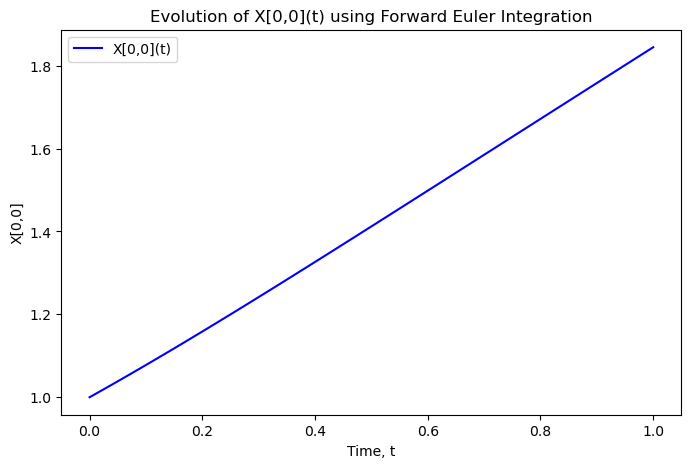

In [3]:
def A1(t):
    return torch.tensor([[1.0 + 0.5 * t, 0.2 * t],
                     [0.3 * t,       1.0 - 0.1 * t]])
    
def A2(t):
    return torch.tensor([[1.0 - 0.2 * t, 0.4 * t],
                     [0.1 * t,       1.0 + 0.3 * t]])
    
def f(X, t):
    return torch.tanh(X @ A1(t)) @ A2(t)

def forward_euler(X0, t0, t_end, dt):
    num_steps = int((t_end - t0) / dt)
    times = torch.linspace(t0, t_end, num_steps + 1)
    X_vals = [X0.clone()]
    t = t0
    X = X0.clone()
    
    for i in range(num_steps):
        X = X + dt * f(X, t)
        t += dt
        X_vals.append(X.clone())
    
    return times, X_vals

t0 = 0.0
t_end = 1.0
dt = 0.01
X0 = torch.eye(2)
times, X_values = forward_euler(X0, t0, t_end, dt)

print("X(t=1) using forward Euler with dt =", dt)
print(X_values[-1])

x00 = [X[0, 0] for X in X_values]

plt.figure(figsize=(8, 5))
plt.plot(times, x00, 'b-', label='X[0,0](t)')
plt.xlabel('Time, t')
plt.ylabel('X[0,0]')
plt.title('Evolution of X[0,0](t) using Forward Euler Integration')
plt.legend()
plt.show()


I created a deep neutral net to predict the swiss roll dataset as defined in the beginning.

In [4]:
def deep_neural_net(A1, A2, n, X0):
    h = 1/n
    X = X0.clone()
    for i in range(n):
        X = X + h*torch.tanh(X@A1[i])@A2[i]
    return X    

I selected some randomized data to test the deep neural network and plotted to see that the prediction was close.\
The crosses on the plot are the predictions, triangles correspond to the randomized set.

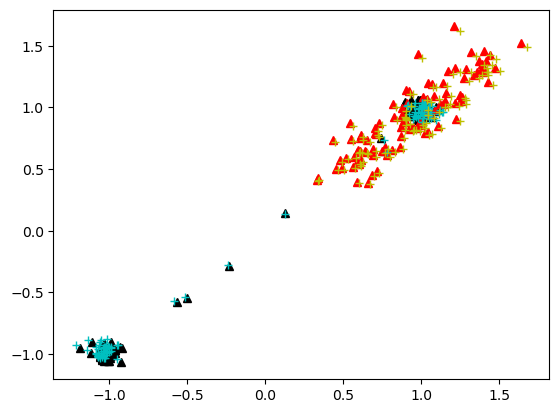

In [24]:
n = 10
A1 = 0.05*torch.randn(n,2,1000)
A2 = 0.05*torch.randn(n,1000,2)
X1c = deep_neural_net(A1, A2, n, X0)
X1d = deep_neural_net(A1, A2, n, X1)

plt.plot(X0[:,0],X0[:,1],'^k')
plt.plot(X1[:,0],X1[:,1],'^r')
plt.plot(X1c[:,0],X1c[:,1],'+c')
plt.plot(X1d[:,0],X1d[:,1],'+y')

In the code below, I use Foward Euler integration with a different $n$ value. 
I arbitrarily chose $n$ to be 10.\
In the code below, the shapes are:\
_$A_1$_ -> $(n, 2, 1000)$ such that for each time index, $A_1$(t) will be 2 x $n$ after permutation.\
_$A_2$_ -> $(n, 1000, 2)$ such that for each time index, $A_2$(t) will be $n$ x 2 after permutation. 

I determine $dt$ from taking the reciprocal of the total amount of permutation subtracted by 1 to preserve $t$ = 1. 

In [6]:
n = 10 
A1 = 0.05 * torch.randn(n, 2, 1000)
A2 = 0.05 * torch.randn(n, 1000, 2)
A1_perm = A1.permute(1, 0, 2)  

def f(X, time_index):
    A1_t = A1_perm[:, :, time_index]
    A2_t = A2[:, time_index, :]
    return torch.tanh(torch.matmul(X, A1_t)) @ A2_t

def forward_euler(X0, dt, num_steps):
    X = X0.clone()
    X_traj = [X.clone()]
    for i in range(num_steps):
        X = X + dt * f(X, time_index=i)
        X_traj.append(X.clone())
    return X_traj

num_steps = A1_perm.shape[-1] 
dt = 1.0 / (num_steps - 1)
X0 = torch.eye(2)
trajectory = forward_euler(X0, dt, num_steps)

X_final = trajectory[-1]
print("X(t=1) computed using forward Euler:")
print(X_final)

X(t=1) computed using forward Euler:
tensor([[9.9949e-01, 1.2384e-04],
        [1.1622e-04, 9.9996e-01]])


Using torch's autograd, I optimizated code that changes $A_1$ and $A_2$ to best fit the data $X_1$ given $X_0$. \
I assumed $T = 1000$ was the timestep and that the learning rate was 0.001 for the optimization.\
I defined the initial state $X(0)$ (a $2x2$ matrix) and the target final state $X(1)$.\
I printed the optimized $A_1$ and $A_2$ at the end. 

In [7]:
n = 10            
T = 1000         
dt = 1.0 / (T - 1) 

A1 = 0.05 * torch.randn(n, 2, T, requires_grad=True)
A2 = 0.05 * torch.randn(n, T, 2, requires_grad=True)
X0 = torch.eye(2)
X1_target = torch.tensor([[1.0, 0.2],
                          [0.3, 0.9]], dtype=torch.float)

def forward_euler(Xi, A1, A2, dt):
    A1_perm = A1.permute(1, 0, 2)  
    X = Xi.clone()
    
    for i in range(T):
        A1_t = A1_perm[:, :, i]
        A2_t = A2[:, i, :]
        dX = torch.tanh(torch.matmul(X, A1_t)) @ A2_t
        X = X + dt * dX
    return X

learning_rate = 0.001
num_epochs = 1000

for epoch in range(num_epochs):
    X_final = forward_euler(X0, A1, A2, dt)
    loss = torch.mean((X_final - X1_target) ** 2)
    grad_A1, grad_A2 = torch.autograd.grad(loss, [A1, A2])

print("\nOptimization complete.")
print("Learned X(t=1):")
print(X_final)
print("\nTarget X(t=1):")
print(X1_target)


Optimization complete.
Learned X(t=1):
tensor([[ 1.0001e+00, -1.9375e-05],
        [ 3.0814e-04,  9.9982e-01]], grad_fn=<AddBackward0>)

Target X(t=1):
tensor([[1.0000, 0.2000],
        [0.3000, 0.9000]])
